<a href="https://colab.research.google.com/github/NarutoxMessi/Capstone-Project/blob/notebooks/part1_data_preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Folders ready:
- data/
- outputs/

Please upload your stock dataset CSV file


Saving ICICIBANK.NS_stock_data.csv to ICICIBANK.NS_stock_data (1).csv

Uploaded file: ICICIBANK.NS_stock_data (1).csv
Raw dataset saved to: data/ICICIBANK.NS_stock_data (1).csv

Dataset loaded successfully.

First 5 rows:
         Date        open        high         low       close    adjclose  \
0  01-04-2022  725.000000  738.299988  723.099976  736.250000  725.883179   
1  04-04-2022  742.000000  749.799988  725.000000  746.599976  736.087402   
2  05-04-2022  746.799988  755.450012  738.000000  741.799988  731.354981   
3  06-04-2022  732.299988  744.900024  732.099976  741.599976  731.157837   
4  07-04-2022  737.099976  757.799988  737.099976  748.549988  738.009949   

     volume        ticker  
0  12658848  ICICIBANK.NS  
1  17192197  ICICIBANK.NS  
2  12290391  ICICIBANK.NS  
3  13518142  ICICIBANK.NS  
4  15087175  ICICIBANK.NS  

Column Data Types:
Date         object
open        float64
high        float64
low         float64
close       float64
adjclose    float64
volume 

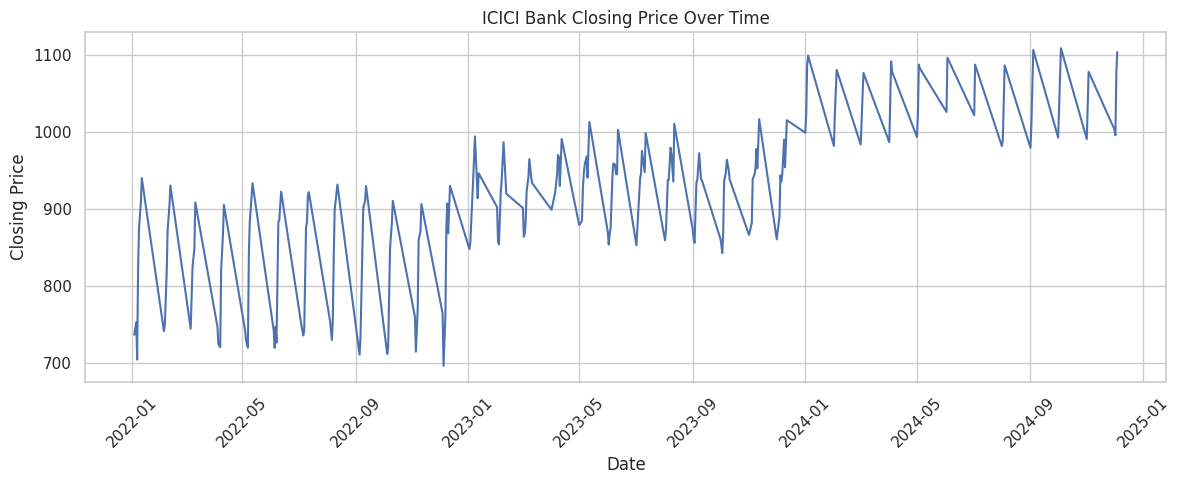

Saved: outputs/line_plot.png


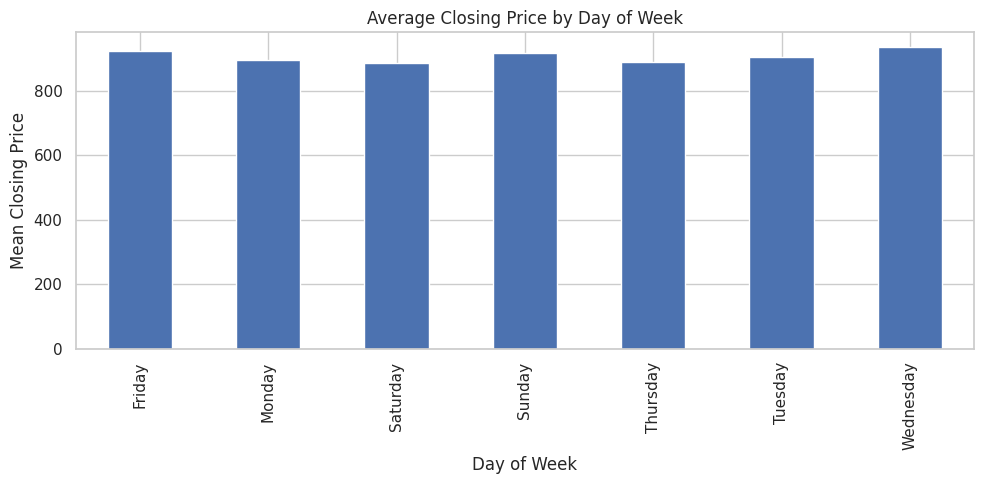

Saved: outputs/bar_chart.png


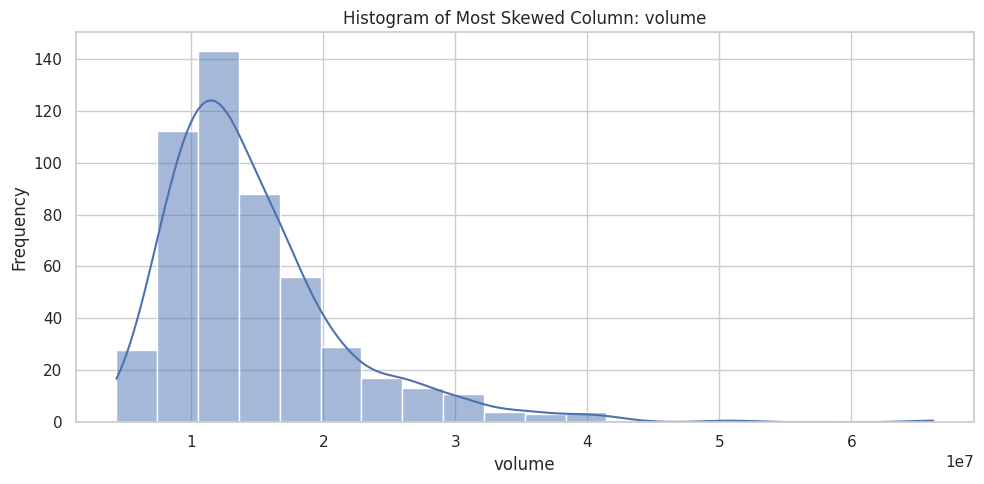

Saved: outputs/histogram_skewed_column.png


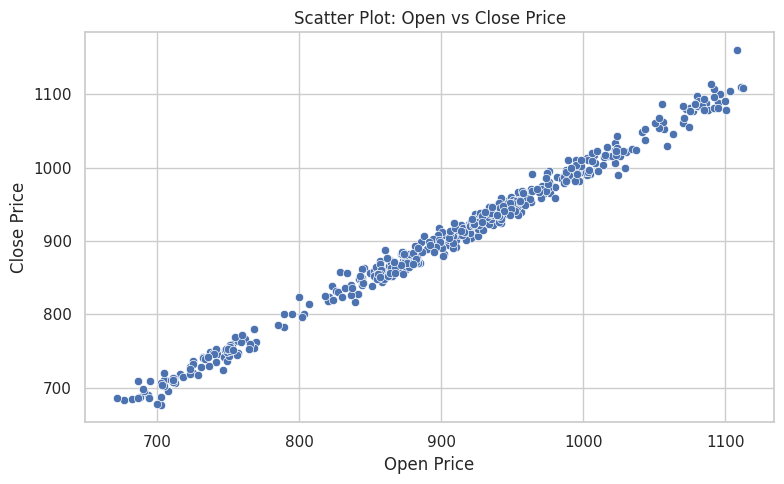

Saved: outputs/scatter_plot.png


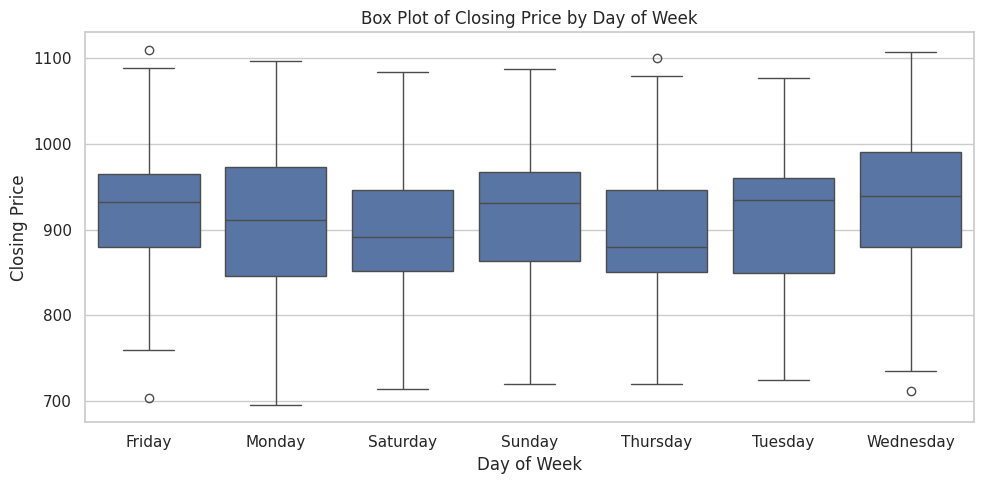

Saved: outputs/box_plot.png

================ CORRELATION HEATMAP ================

Pearson Correlation Matrix:
                  open      high       low     close  adj_close    volume  \
open          1.000000  0.997623  0.998052  0.995435   0.995287  0.165712   
high          0.997623  1.000000  0.997876  0.998308   0.998119  0.176371   
low           0.998052  0.997876  1.000000  0.998258   0.998016  0.155405   
close         0.995435  0.998308  0.998258  1.000000   0.999691  0.163598   
adj_close     0.995287  0.998119  0.998016  0.999691   1.000000  0.162336   
volume        0.165712  0.176371  0.155405  0.163598   0.162336  1.000000   
year          0.790250  0.793669  0.785541  0.789316   0.794471  0.193735   
month         0.008719  0.004074  0.011949  0.005722   0.007412  0.009133   
price_range   0.142733  0.181615  0.117174  0.150057   0.150825  0.342882   
daily_return -0.036504  0.017720  0.013200  0.058203   0.056536 -0.017686   

                  year     month  price_

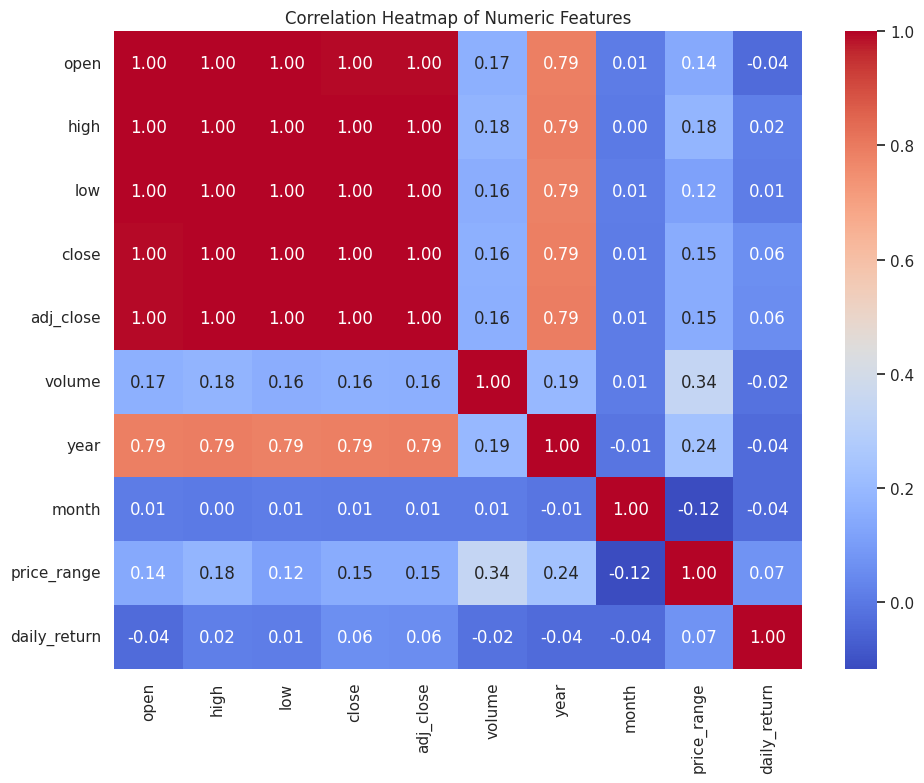

Saved: outputs/correlation_heatmap.png

Highest absolute correlation pair: ('close', 'adj_close')
Correlation value: 0.9996906988688847

================ IMPUTATION STRATEGY COMPARISON ================

Top 2 skewed columns: ['volume', 'price_range']

Column: volume
Mean: 14792735.201565558
Median: 13008311.0

Column: price_range
Mean: 15.59041419960861
Median: 14.20001220000006

Null count after imputation of top 2 skewed columns:
volume         0
price_range    0
dtype: int64

================ SPEARMAN RANK CORRELATION ================

Spearman Correlation Matrix:
                  open      high       low     close  adj_close    volume  \
open          1.000000  0.996932  0.997040  0.993745   0.993262  0.200007   
high          0.996932  1.000000  0.997472  0.997387   0.996541  0.204599   
low           0.997040  0.997472  1.000000  0.997820   0.997173  0.188384   
close         0.993745  0.997387  0.997820  1.000000   0.999131  0.193093   
adj_close     0.993262  0.996541  0.99717

In [6]:
# ============================================================
# PART 1 - DATA PREPARATION & EXPLORATION
# Google Colab Final Version
# Dataset: ICICIBANK.NS_stock_data.csv
# ============================================================

# ------------------------------------------------------------
# 0. IMPORT LIBRARIES
# ------------------------------------------------------------
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# ------------------------------------------------------------
# 1. CREATE PROJECT FOLDERS
# ------------------------------------------------------------
os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Folders ready:")
print("- data/")
print("- outputs/")

# ------------------------------------------------------------
# 2. UPLOAD DATASET IN COLAB
# ------------------------------------------------------------
print("\nPlease upload your stock dataset CSV file")
uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("No file uploaded. Please upload a CSV file.")

# Get uploaded filename
uploaded_file_name = list(uploaded.keys())[0]
print(f"\nUploaded file: {uploaded_file_name}")

# Save a copy of the uploaded raw dataset inside data/
raw_data_path = os.path.join("data", uploaded_file_name)

# If the uploaded file is not already in data/, copy it
if uploaded_file_name != raw_data_path:
    shutil.copy(uploaded_file_name, raw_data_path)

print(f"Raw dataset saved to: {raw_data_path}")

# ------------------------------------------------------------
# 3. LOAD DATASET
# ------------------------------------------------------------
df = pd.read_csv(raw_data_path)

print("\nDataset loaded successfully.")
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn Data Types:")
print(df.dtypes)

print("\nDataFrame Shape:")
print(df.shape)

if df.empty:
    raise ValueError("The uploaded dataset is empty. Please upload the correct CSV file.")

# ------------------------------------------------------------
# 4. STANDARDIZE COLUMN NAMES
# ------------------------------------------------------------
df.columns = df.columns.str.strip().str.lower()

print("\nStandardized Column Names:")
print(df.columns.tolist())

# Rename common column variations
rename_map = {}
if 'adj close' in df.columns:
    rename_map['adj close'] = 'adj_close'
if 'adjclose' in df.columns:
    rename_map['adjclose'] = 'adj_close'

df.rename(columns=rename_map, inplace=True)

# ------------------------------------------------------------
# 5. NULL VALUE ANALYSIS
# ------------------------------------------------------------
print("\n================ NULL VALUE ANALYSIS ================\n")

null_counts = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df)) * 100

null_report = pd.DataFrame({
    'Null Count': null_counts,
    'Null Percentage': null_percent
})

print(null_report)

high_null_cols = null_report[null_report['Null Percentage'] > 20]
print("\nColumns with more than 20% null values:")
print(high_null_cols if not high_null_cols.empty else "None")

# Fill numeric columns having <20% null values using median
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    if null_percent[col] < 20 and df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("\nNull values after median imputation:")
print(df.isnull().sum())

# ------------------------------------------------------------
# 6. DUPLICATE DETECTION AND REMOVAL
# ------------------------------------------------------------
print("\n================ DUPLICATE ANALYSIS ================\n")

duplicates_before = df.duplicated().sum()
print("Number of duplicate rows before removal:", duplicates_before)

null_before_dup_removal = (df.isnull().sum() / len(df)) * 100

df = df.drop_duplicates()

duplicates_after = df.duplicated().sum()
print("Number of duplicate rows after removal:", duplicates_after)
print("Rows removed:", duplicates_before)

null_after_dup_removal = (df.isnull().sum() / len(df)) * 100

dup_null_comparison = pd.DataFrame({
    'Null % Before Duplicate Removal': null_before_dup_removal,
    'Null % After Duplicate Removal': null_after_dup_removal
})

print("\nNull percentage before vs after duplicate removal:")
print(dup_null_comparison)

# ------------------------------------------------------------
# 7. DATA TYPE CORRECTION
# ------------------------------------------------------------
print("\n================ DATA TYPE CORRECTION ================\n")

memory_before = df.memory_usage(deep=True).sum()
print("Memory usage before dtype conversion:", memory_before, "bytes")

# Convert date column
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Convert ticker to category
if 'ticker' in df.columns:
    df['ticker'] = df['ticker'].astype('category')

# Create date-based columns
if 'date' in df.columns:
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day_name'] = df['date'].dt.day_name().astype('category')

memory_after = df.memory_usage(deep=True).sum()
print("Memory usage after dtype conversion:", memory_after, "bytes")
print("Memory reduced by:", memory_before - memory_after, "bytes")

print("\nUpdated Data Types:")
print(df.dtypes)

# ------------------------------------------------------------
# 8. FEATURE ENGINEERING
# ------------------------------------------------------------
print("\n================ FEATURE ENGINEERING ================\n")

required_cols = ['high', 'low', 'close', 'open']
if all(col in df.columns for col in required_cols):
    df['price_range'] = df['high'] - df['low']
    df['daily_return'] = ((df['close'] - df['open']) / df['open']) * 100
    print("Created: price_range, daily_return")
else:
    print("Required columns for feature engineering not fully available.")

# Volume category
if 'volume' in df.columns:
    try:
        df['volume_category'] = pd.qcut(
            df['volume'],
            q=3,
            labels=['Low', 'Medium', 'High'],
            duplicates='drop'
        )
        df['volume_category'] = df['volume_category'].astype('category')
        print("Created: volume_category")
    except Exception as e:
        print("Volume category could not be created:", e)

print("\nPreview after feature engineering:")
print(df.head())

# ------------------------------------------------------------
# 9. DESCRIPTIVE STATISTICS AND SKEWNESS
# ------------------------------------------------------------
print("\n================ DESCRIPTIVE STATISTICS ================\n")

numeric_cols = df.select_dtypes(include=[np.number]).columns

if len(numeric_cols) == 0:
    raise ValueError("No numeric columns available for descriptive statistics.")

print("Descriptive Statistics:")
print(df[numeric_cols].describe())

print("\nSkewness of Numeric Columns:")
skewness = df[numeric_cols].skew()
print(skewness)

most_skewed_col = skewness.abs().idxmax()
print("\nColumn with highest absolute skewness:", most_skewed_col)
print("Skewness value:", skewness[most_skewed_col])

# ------------------------------------------------------------
# 10. OUTLIER DETECTION USING IQR
# ------------------------------------------------------------
print("\n================ OUTLIER DETECTION (IQR) ================\n")

outlier_cols = []
if 'volume' in df.columns:
    outlier_cols.append('volume')
if 'daily_return' in df.columns:
    outlier_cols.append('daily_return')

if len(outlier_cols) == 0:
    print("No target columns available for outlier detection.")
else:
    for col in outlier_cols:
        col_data = df[col].dropna()
        if len(col_data) == 0:
            print(f"\nColumn: {col} has no valid data.")
            continue

        Q1 = col_data.quantile(0.25)
        Q3 = col_data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        print(f"\nColumn: {col}")
        print("Q1 =", Q1)
        print("Q3 =", Q3)
        print("IQR =", IQR)
        print("Lower Bound =", lower_bound)
        print("Upper Bound =", upper_bound)
        print("Number of Outliers =", outliers.shape[0])

# ------------------------------------------------------------
# 11. VISUALIZATIONS
# ------------------------------------------------------------
print("\n================ GENERATING VISUALIZATIONS ================\n")

sns.set(style="whitegrid")

# 11.1 Line Plot
if 'date' in df.columns and 'close' in df.columns:
    temp_df = df[['date', 'close']].dropna().sort_values('date')
    if not temp_df.empty:
        plt.figure(figsize=(12, 5))
        plt.plot(temp_df['date'], temp_df['close'])
        plt.title("ICICI Bank Closing Price Over Time")
        plt.xlabel("Date")
        plt.ylabel("Closing Price")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig("outputs/line_plot.png", dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()
        print("Saved: outputs/line_plot.png")

# 11.2 Bar Chart
if 'day_name' in df.columns and 'close' in df.columns:
    mean_close_by_day = df.groupby('day_name', observed=False)['close'].mean().dropna()
    if not mean_close_by_day.empty:
        plt.figure(figsize=(10, 5))
        mean_close_by_day.plot(kind='bar')
        plt.title("Average Closing Price by Day of Week")
        plt.xlabel("Day of Week")
        plt.ylabel("Mean Closing Price")
        plt.tight_layout()
        plt.savefig("outputs/bar_chart.png", dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()
        print("Saved: outputs/bar_chart.png")

# 11.3 Histogram of Most Skewed Column
if most_skewed_col in df.columns and df[most_skewed_col].dropna().shape[0] > 0:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[most_skewed_col].dropna(), bins=20, kde=True)
    plt.title(f"Histogram of Most Skewed Column: {most_skewed_col}")
    plt.xlabel(most_skewed_col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig("outputs/histogram_skewed_column.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Saved: outputs/histogram_skewed_column.png")

# 11.4 Scatter Plot
if 'open' in df.columns and 'close' in df.columns:
    scatter_df = df[['open', 'close']].dropna()
    if not scatter_df.empty:
        plt.figure(figsize=(8, 5))
        sns.scatterplot(x='open', y='close', data=scatter_df)
        plt.title("Scatter Plot: Open vs Close Price")
        plt.xlabel("Open Price")
        plt.ylabel("Close Price")
        plt.tight_layout()
        plt.savefig("outputs/scatter_plot.png", dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()
        print("Saved: outputs/scatter_plot.png")

# 11.5 Box Plot
if 'day_name' in df.columns and 'close' in df.columns:
    box_df = df[['day_name', 'close']].dropna()
    if not box_df.empty:
        plt.figure(figsize=(10, 5))
        sns.boxplot(x='day_name', y='close', data=box_df)
        plt.title("Box Plot of Closing Price by Day of Week")
        plt.xlabel("Day of Week")
        plt.ylabel("Closing Price")
        plt.tight_layout()
        plt.savefig("outputs/box_plot.png", dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()
        print("Saved: outputs/box_plot.png")

# ------------------------------------------------------------
# 12. CORRELATION HEATMAP
# ------------------------------------------------------------
print("\n================ CORRELATION HEATMAP ================\n")

numeric_df = df[numeric_cols].dropna(axis=1, how='all')

if numeric_df.shape[1] >= 2:
    pearson_corr = numeric_df.corr()
    print("Pearson Correlation Matrix:")
    print(pearson_corr)

    plt.figure(figsize=(10, 8))
    sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Heatmap of Numeric Features")
    plt.tight_layout()
    plt.savefig("outputs/correlation_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Saved: outputs/correlation_heatmap.png")

    corr_pairs = pearson_corr.abs().unstack()
    corr_pairs = corr_pairs[corr_pairs < 1]

    if len(corr_pairs) > 0:
        highest_corr_pair = corr_pairs.idxmax()
        highest_corr_value = corr_pairs.max()
        print("\nHighest absolute correlation pair:", highest_corr_pair)
        print("Correlation value:", highest_corr_value)
else:
    pearson_corr = None
    print("Not enough numeric columns for correlation heatmap.")

# ------------------------------------------------------------
# 13a. IMPUTATION STRATEGY COMPARISON
# ------------------------------------------------------------
print("\n================ IMPUTATION STRATEGY COMPARISON ================\n")

top2_skewed = skewness.abs().sort_values(ascending=False).head(2).index.tolist()
print("Top 2 skewed columns:", top2_skewed)

for col in top2_skewed:
    if col in df.columns:
        print(f"\nColumn: {col}")
        print("Mean:", df[col].mean())
        print("Median:", df[col].median())

        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())

print("\nNull count after imputation of top 2 skewed columns:")
print(df[top2_skewed].isnull().sum())

# ------------------------------------------------------------
# 13b. SPEARMAN RANK CORRELATION
# ------------------------------------------------------------
print("\n================ SPEARMAN RANK CORRELATION ================\n")

if numeric_df.shape[1] >= 2 and pearson_corr is not None:
    spearman_corr = numeric_df.corr(method='spearman')
    print("Spearman Correlation Matrix:")
    print(spearman_corr)

    diff_matrix = (spearman_corr - pearson_corr).abs()
    print("\nAbsolute Difference |Spearman - Pearson|:")
    print(diff_matrix)

    diff_pairs = diff_matrix.unstack()
    diff_pairs = diff_pairs[
        diff_pairs.index.get_level_values(0) != diff_pairs.index.get_level_values(1)
    ]
    diff_pairs = diff_pairs.sort_values(ascending=False)

    top3_pairs = diff_pairs.drop_duplicates().head(3)
    print("\nTop 3 pairs with largest |Spearman - Pearson| difference:")
    print(top3_pairs)
else:
    print("Not enough numeric columns for Spearman correlation analysis.")

# ------------------------------------------------------------
# 13c. GROUPED AGGREGATION
# ------------------------------------------------------------
print("\n================ GROUPED AGGREGATION ================\n")

if 'day_name' in df.columns and 'close' in df.columns:
    grouped = df.groupby('day_name', observed=False)['close'].agg(['mean', 'std', 'count'])
    print(grouped)

    if not grouped.empty:
        highest_mean_group = grouped['mean'].idxmax()
        highest_std_group = grouped['std'].idxmax()

        print("\nGroup with highest mean:", highest_mean_group)
        print("Group with highest std:", highest_std_group)

        highest_mean = grouped['mean'].max()
        lowest_mean = grouped['mean'].min()

        if pd.notnull(lowest_mean) and lowest_mean != 0:
            mean_ratio = highest_mean / lowest_mean
            print("Ratio of highest group mean to lowest group mean:", mean_ratio)

# ------------------------------------------------------------
# 14. FINAL CLEANING BEFORE SAVE
# ------------------------------------------------------------
print("\n================ FINAL CLEANING BEFORE SAVE ================\n")

# Optional: remove rows where date is invalid, if date column exists
if 'date' in df.columns:
    before_rows = df.shape[0]
    df = df.dropna(subset=['date'])
    after_rows = df.shape[0]
    print(f"Removed {before_rows - after_rows} rows with invalid date values.")

# Reset index after all cleaning
df.reset_index(drop=True, inplace=True)

print("Final DataFrame shape before saving:", df.shape)

if df.empty:
    raise ValueError("DataFrame became empty before saving. Check earlier processing steps.")

# ------------------------------------------------------------
# 15. SAVE CLEANED DATASET
# ------------------------------------------------------------
print("\nSaving cleaned dataset...")

cleaned_file_path = "https://github.com/NarutoxMessi/Capstone-Project/blob/data/cleaned_data.csv"
df.to_csv(cleaned_file_path, index=False)

print(f"Saved: {cleaned_file_path}")
print("Final cleaned dataset shape:", df.shape)

# ------------------------------------------------------------
# 16. SHOW GENERATED FILES
# ------------------------------------------------------------
print("\n================ GENERATED FILES ================\n")

print("Inside data/:")
for f in os.listdir("data"):
    print(" -", f)

print("\nInside outputs/:")
for f in os.listdir("outputs"):
    print(" -", f)

# ------------------------------------------------------------
# 17. OPTIONAL DOWNLOAD FILES IN COLAB
# ------------------------------------------------------------
print("\nIf you want to download files manually in Colab, use:")
print("files.download('data/cleaned_data.csv')")

# Example:
# files.download('data/cleaned_data.csv')